[Sascha Spors](https://orcid.org/0000-0001-7225-9992),
Professorship Signal Theory and Digital Signal Processing,
[Institute of Communications Engineering (INT)](https://www.int.uni-rostock.de/),
Faculty of Computer Science and Electrical Engineering (IEF),
[University of Rostock, Germany](https://www.uni-rostock.de/en/)

# Tutorial Signals and Systems (Signal- und Systemtheorie)

Summer Semester 2022 (Bachelor Course #24015)

- lecture: https://github.com/spatialaudio/signals-and-systems-lecture
- tutorial: https://github.com/spatialaudio/signals-and-systems-exercises

Feel free to contact lecturer [frank.schultz@uni-rostock.de](https://orcid.org/0000-0002-3010-0294)

## Übung / Exercise 5

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import scipy.signal as signal
import sympy as sp
import sys

In [2]:
cur_fol = os.getcwd()
print(cur_fol)
sys.path.append(cur_fol + '/../')

/Users/fs446/git/signals-and-systems-exercises/laplace_system_analysis


In [3]:
from sig_sys_tools import plot_splane, group_delay, plot_clti_analysis

In [4]:
t = np.arange(0, 10, 0.1)
w = np.logspace(-2, 2, 2**10)


def plot_lti_system():
    plt.figure(figsize=(12, 14))
    plt.subplot(3, 2, 1)
    plt.plot(th, h)
    plt.xlabel(r'$t$ / s')
    plt.ylabel(r'$h(t)$')
    plt.title('Impulse Response')
    plt.grid(True)

    plt.subplot(3, 2, 2)
    plt.semilogx(w, Hlevel_dB)
    plt.xlabel(r'$\omega$ / (rad/s)')
    plt.ylabel(r'$20 \mathrm{log}_{10}|H(\mathrm{j}\omega)|$ / dB')
    plt.title('Level Response')
    plt.grid(True)

    plt.subplot(3, 2, 3)
    plt.plot(the, he)
    plt.xlabel(r'$t$ / s')
    plt.ylabel(r'$h_\epsilon(t)$')
    plt.title('Step Response')
    plt.grid(True)

    plt.subplot(3, 2, 4)
    plt.semilogx(w, Hphase_deg)
    plt.xlabel(r'$\omega$ / (rad/s)')
    plt.ylabel(r'$\angle H(\mathrm{j}\omega)$ / deg')
    plt.title('Phase Response')
    plt.grid(True)

    plt.subplot(3, 2, 5)
    plt.plot(H.real, H.imag)
    plt.xlabel(r'$\Re\{H(\mathrm{j}\omega)\}$')
    plt.ylabel(r'$\Im\{H(\mathrm{j}\omega)\}$')
    plt.title('Nyquist Plot')
    plt.grid(True)

    plt.subplot(3, 2, 6)
    plt.plot(Hphase_deg, Hlevel_dB)
    plt.xlabel(r'$\angle H(\mathrm{j}\omega)$ / deg')
    plt.ylabel(r'$20 \mathrm{log}_{10}|H(\mathrm{j}\omega)|$ / dB')
    plt.title('Nichols Plot')
    plt.grid(True)

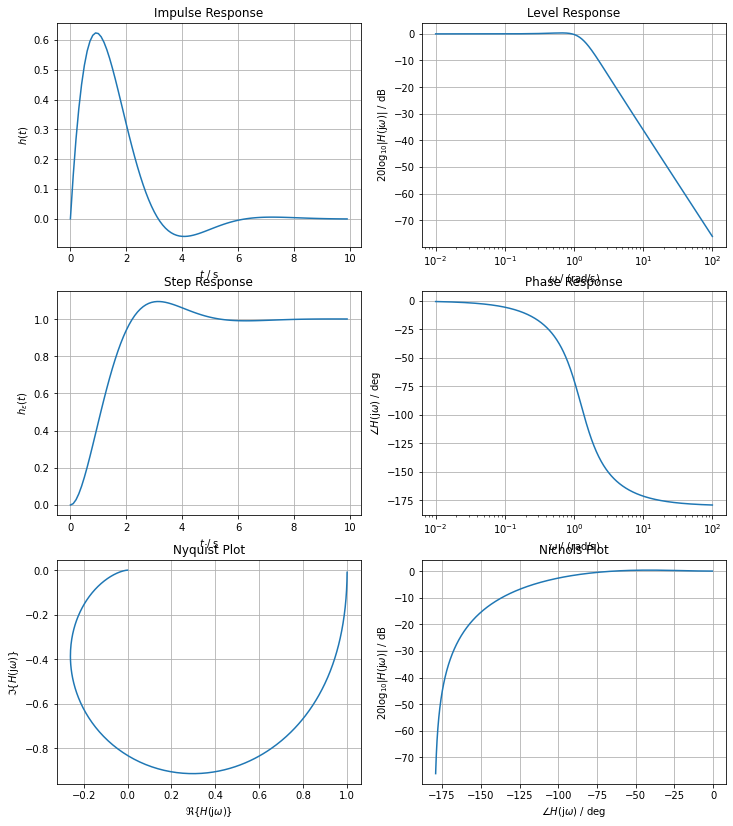

In [5]:
# pole / zero / gain representation
# sz = np.array([0])
# sp = np.array([0, -3/4+1j, -3/4-1j])
sz = np.array([])
sp = np.array([-3/4+1j, -3/4-1j])
H0 = 25/16
sys = signal.lti(sz, sp, H0)

th, h = signal.impulse(sys, T=t, X0=None)
the, he = signal.step(sys, T=t, X0=None)
w, Hlevel_dB, Hphase_deg = sys.bode(w)
w, H = sys.freqresp(w)

plot_lti_system()
plt.savefig('lowpass2nd_44EB4169E9.pdf')

/Users/fs446/opt/anaconda3/envs/mydsp/lib/python3.9/site-packages/scipy/signal/_filter_design.py:1709: BadCoefficients: Badly conditioned filter coefficients (numerator): the results may be meaningless
  warnings.warn("Badly conditioned filter coefficients (numerator): the "


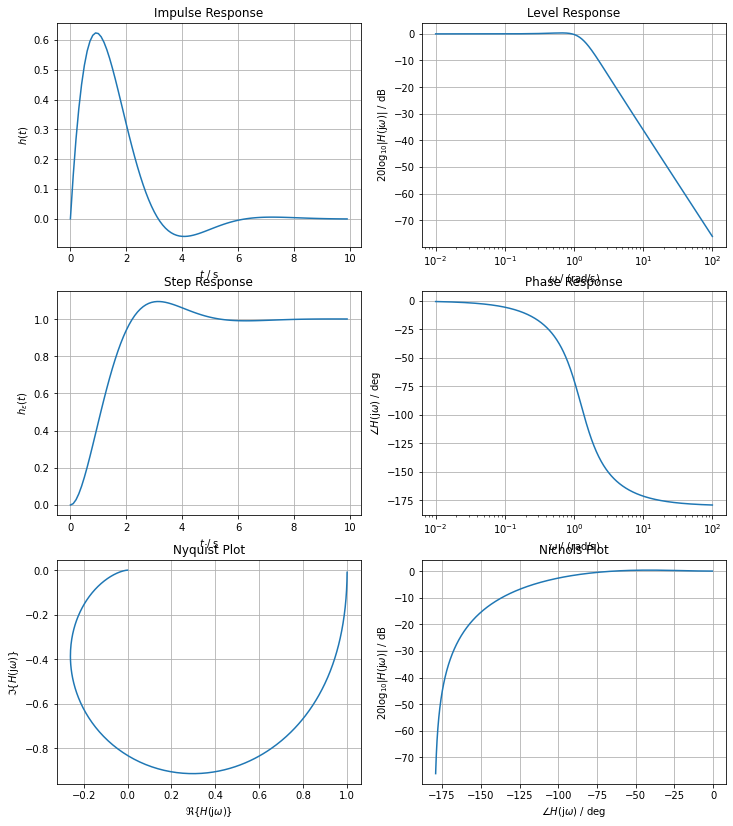

In [6]:
# transfer function coefficients representation
B = (0, 0, 1)
A = (16/25, 24/25, 1)
th, h = signal.impulse([B, A], T=t, X0=None)
the, he = signal.step([B, A], T=t, X0=None)
w, H = signal.freqs(B, A, worN=w)
Hlevel_dB = 20*np.log10(np.abs(H))
Hphase_deg = np.angle(H) * 180/np.pi

plot_lti_system()
plt.savefig('lowpass2nd_44EB4169E9.pdf')

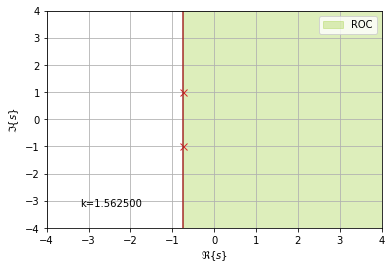

In [7]:
plot_splane(z=sz, p=sp, k=H0)

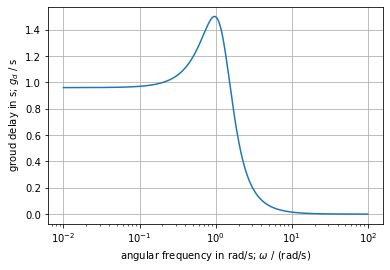

In [8]:
wgd, gd = group_delay(z=sz, p=sp, w=w)
plt.plot(wgd, gd)
plt.xscale('log')
plt.xlabel(r'angular frequency in rad/s; $\omega$ / (rad/s)')
plt.ylabel(r' groud delay in s; $g_d$ / s')
plt.grid(True)

(array([ 0.1       ,  0.10004607,  0.10009216, ...,  9.99079298,
         9.99539543, 10.        ]),
 array([ 0.99713288-0.09634134j,  0.99713019-0.09638603j,
         0.9971275 -0.09643075j, ..., -0.0155412 -0.00237043j,
        -0.015527  -0.00236714j, -0.01551281-0.00236386j]))

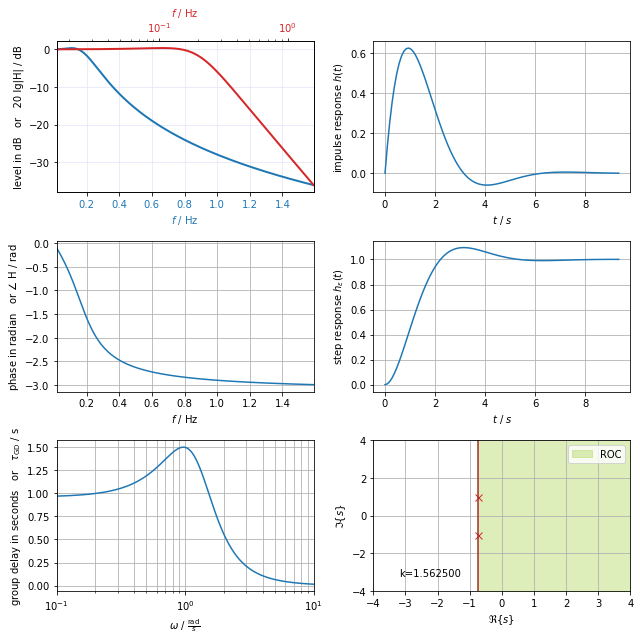

In [9]:
plot_clti_analysis(z=sz, p=sp, k=H0)

## Copyright

This tutorial is provided as Open Educational Resource (OER), to be found at
https://github.com/spatialaudio/signals-and-systems-exercises
accompanying the OER lecture
https://github.com/spatialaudio/signals-and-systems-lecture.
Both are licensed under a) the Creative Commons Attribution 4.0 International
License for text and graphics and b) the MIT License for source code.
Please attribute material from the tutorial as *Frank Schultz,
Continuous- and Discrete-Time Signals and Systems - A Tutorial Featuring
Computational Examples, University of Rostock* with
``github URL, commit number and/or version tag, year, (file name and/or content)``.